# Análise Exploratória de Dados (EDA) 📊
### Telco Customer Churn

# 📋 1. Visão Geral da Base

Nesta etapa, será realizada uma análise inicial do conjunto de dados para compreender sua estrutura, tipos de variáveis, presença de valores nulos e características gerais antes de qualquer transformação.

In [1]:
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# Configuracoes de visualizacao
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)

## 1.1 Carregamento dos Dados

In [2]:
df = pd.read_excel("../data/raw/Telco_customer_churn.xlsx")

print(f"Shape: {df.shape}")
df.head()


Shape: (7043, 33)


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


💡 **Observação:**

A base de dados possui **7.043 registros** e **33 variáveis**, representando um volume adequado para análise e modelagem. As primeiras linhas revelam clientes de **Los Angeles / California**, o que já levanta a suspeita de que `Country`, `State` e colunas de geolocalização podem ter baixa variância. Nota-se também que `Total Charges` aparece como string — anomalia a investigar — e que `Churn Label` e `Churn Value` carregam a mesma informação em formatos diferentes (`Yes/No` vs `1/0`).

## 1.2 Inspeção de Tipos e Valores Nulos

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

💡 **Observação:**

| Achado | Detalhe |
|--------|---------|
| **`Total Charges` como `object`** | Deveria ser `float64`. Indica valores não numéricos que impedem a inferência automática do tipo. |
| **`Churn Reason` tem 5.174 nulos** | Apenas 1.869 registros preenchidos — exatamente os clientes que fizeram churn. Os nulos são estruturais, não sujeira. |
| **Sem outros nulos aparentes** | Todas as demais colunas mostram 7.043 non-null, o que é positivo para a qualidade geral do dataset. |

> **Atenção:** O `.info()` reporta `Total Charges` com 7.043 non-null, mas isso **não significa ausência de problemas** — strings vazias `""` são contadas como valores válidos pelo pandas.

## 1.3 Resumo Estatístico

In [4]:
print("=== Variaveis Numericas ===")
display(df.describe())

print("=== Variaveis Categoricas ===")
display(df.describe(include="object"))

=== Variaveis Numericas ===


,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


=== Variaveis Categoricas ===


,CustomerID,Country,State,City,Lat Long,Gender,Senior Citizen,Partner,Dependents,Phone Service,...,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Total Charges,Churn Label,Churn Reason
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043,7043,1869
unique,7043,1,1,1129,1652,2,2,2,2,2,...,3,3,3,3,3,2,4,6531,2,20
top,3668-QPYBK,United States,California,Los Angeles,"34.159534, -116.425984",Male,No,No,No,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,,No,Attitude of support person
freq,1,7043,7043,305,5,3555,5901,3641,5416,6361,...,3095,3473,2810,2785,3875,4171,2365,11,5174,192


💡 **Observação:**

**Variáveis Numéricas**

| Coluna | Achado | Ação |
|--------|--------|------|
| `Count` | Constante (`std = 0`, sempre = 1) | **Remover** |
| `Tenure Months` | Mínimo = 0 — clientes com zero meses de contrato | **Investigar** |
| `Monthly Charges` | Range razoável: R$18 a R$119, média ~R$65 | Manter |
| `Churn Value` | Média = 0.265 → **~26,5% de churn** | Target desbalanceado, requer atenção no treino |
| `Churn Score` / `CLTV` | Derivados do churn conhecido | **Remover** (data leakage) |

**Variáveis Categóricas**

| Coluna | Achado | Ação |
|--------|--------|------|
| `Country` | `unique = 1` — só "United States" | **Remover** (sem variância) |
| `State` | `unique = 1` — só "California" | **Remover** (sem variância) |
| `CustomerID` | `unique = 7043` — todos distintos | **Remover** (identificador) |
| `Total Charges` | `top = ""` com `freq = 11` | **Corrigir** (11 strings vazias) |
| `Churn Reason` | 20 categorias únicas, só em clientes que saíram | **Remover** (data leakage) |
| `Churn Label` | Duplicata de `Churn Value` | **Remover** (redundante) |

O dataset está **razoavelmente limpo**, mas exige três correções antes da modelagem: converter `Total Charges` para `float`, remover colunas com leakage e constantes, e investigar os registros com `Tenure Months == 0`.

# 🧹 2. Limpeza de Dados e Correção de Tipos

Nesta etapa, serão corrigidas as inconsistências identificadas na inspeção inicial: a conversão de `Total Charges` para tipo numérico e o tratamento dos registros com valores inválidos.

In [5]:
# --- Corrigindo o tipo de 'Total Charges' ---
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")

# Verificando quantos NaN foram gerados
n_nulls = df["Total Charges"].isna().sum()
print(f"Total Charges: {n_nulls} valores NaN gerados.")

# --- Investigando os registros com problema ---
mask_null = df["Total Charges"].isna()
print("\nRegistros com Total Charges nulo:")
display(df[mask_null][["CustomerID", "Tenure Months", "Monthly Charges", "Total Charges", "Churn Label"]])


Total Charges: 11 valores NaN gerados.

Registros com Total Charges nulo:


,CustomerID,Tenure Months,Monthly Charges,Total Charges,Churn Label
2234,4472-LVYGI,0,52.55,NaN,No
2438,3115-CZMZD,0,20.25,NaN,No
2568,5709-LVOEQ,0,80.85,NaN,No
2667,4367-NUYAO,0,25.75,NaN,No
2856,1371-DWPAZ,0,56.05,NaN,No
4331,7644-OMVMY,0,19.85,NaN,No
4687,3213-VVOLG,0,25.35,NaN,No
5104,2520-SGTTA,0,20.00,NaN,No
5719,2923-ARZLG,0,19.70,NaN,No
6772,4075-WKNIU,0,73.35,NaN,No


## 2.1 Investigação dos Valores Nulos em `Total Charges`

Clientes com `Tenure Months == 0` não geraram cobrança ainda — por isso o campo está vazio. A célula abaixo confirma essa hipótese antes de decidir o que fazer com esses registros.

In [6]:
# Verificando sobreposicao: todos os nulos de Total Charges tem Tenure Months = 0 ? 
tenure_zero = df["Tenure Months"] == 0
print(f"Clientes com Tenure == 0: {tenure_zero.sum()}")
print(f"Desses, com Total Charges nulo: {(tenure_zero & mask_null).sum()}")

# Se a sobreposicao for total, a decisao mais segura seria remover esses registros (pois representam clientes sem historico de uso).
df = df[~mask_null].copy()
df = df.reset_index(drop=True)

print(f"\nShape apos remocao: {df.shape}")
print(f"Total Charges: {df['Total Charges'].dtype}")

Clientes com Tenure == 0: 11
Desses, com Total Charges nulo: 11

Shape apos remocao: (7032, 33)
Total Charges: float64


💡 **Observação:**

| Ação | Detalhe |
|------|---------|
| `Total Charges` convertido para `float64` | 11 strings vazias viraram `NaN` via `pd.to_numeric(..., errors='coerce')` |
| Registros removidos | Os 11 casos com `NaN` correspondiam a clientes com `Tenure Months == 0` — sem histórico de uso |
| Shape final | 7.032 registros × 33 colunas |

Remover esses 11 registros é preferível a imputar, pois clientes sem nenhum mês de contrato não carregam sinal preditivo para churn.

# 🎯 3. Seleção de Variáveis

Nesta etapa, serão removidas as colunas que não contribuem para a modelagem: identificadores únicos, variáveis geográficas sem variância, e variáveis com risco de data leakage — ou seja, que derivam do próprio evento de churn que estamos tentando prever.

In [7]:
# Colunas agrupadas por motivo de remoção para facilitar auditoria futura
cols_to_drop = [
    # Sem variância — valor único em todo o dataset
    "Count", "Country", "State",
    # Identificadores — não carregam sinal preditivo
    "CustomerID", "Lat Long",
    # Geolocalização — granularidade excessiva para um modelo tabular de churn
    "Latitude", "Longitude", "Zip Code", "City",
    # Data leakage — derivados do churn já conhecido
    "Churn Score", "CLTV", "Churn Reason",
    # Redundante — duplicata categórica do target numérico
    "Churn Label",
]

df = df.drop(columns=cols_to_drop)

print(f"Shape após remoção: {df.shape}")
print(f"\nColunas restantes ({df.shape[1]}):")
print(df.columns.tolist())


Shape após remoção: (7032, 20)

Colunas restantes (20):
['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Value']


💡 **Observação:**

Reduzimos de **33 → 20 colunas**, eliminando ruído sem perda de informação preditiva. Destacam-se as remoções de `Churn Score`, `CLTV` e `Churn Reason`, que são **derivados do churn já conhecido** e causariam vazamento de dados (data leakage) se mantidos no treino. A variável alvo é **`Churn Value`** (1 = churn, 0 = retido), e as 19 features restantes serão analisadas nas próximas seções.

# 🎯 4. Análise da Variável Alvo — `Churn Value`

Nesta etapa, será analisada a distribuição da variável de churn, com o objetivo de identificar o nível de desbalanceamento entre as classes e definir a estratégia de avaliação mais adequada.

,Count,Percentage (%)
No Churn (0),5163,73.42
Churn (1),1869,26.58


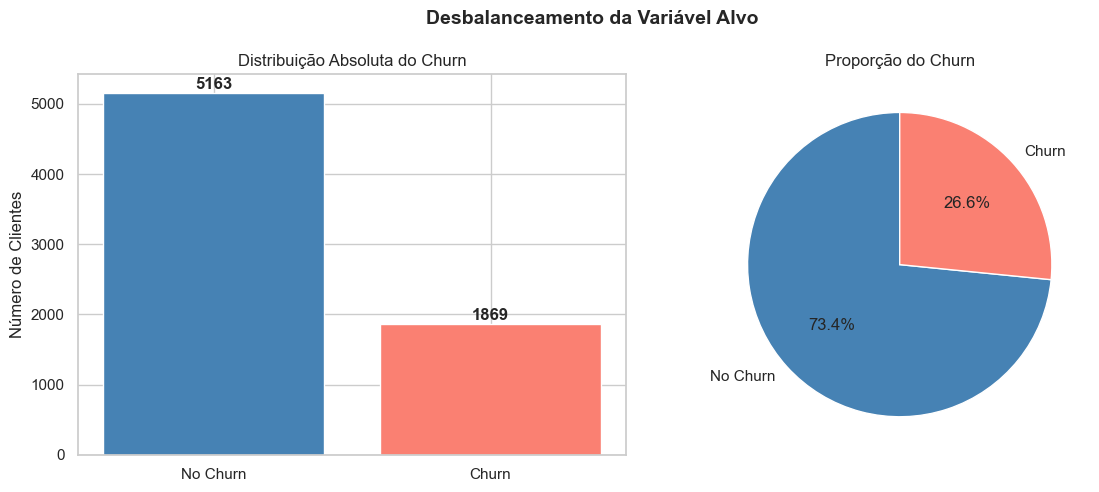

In [8]:
# Contagem absoluta e percentual de cada classe
churn_counts = df["Churn Value"].value_counts()
churn_pct = df["Churn Value"].value_counts(normalize=True) * 100

summary = pd.DataFrame({
    "Count": churn_counts,
    "Percentage (%)": churn_pct.round(2),
})
summary.index = ["No Churn (0)", "Churn (1)"]
display(summary)

# --- Visualização ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico 1: contagem absoluta
axes[0].bar(
    ["No Churn", "Churn"],
    churn_counts.values,
    color=["steelblue", "salmon"],
    edgecolor="white",
)
axes[0].set_title("Distribuição Absoluta do Churn")
axes[0].set_ylabel("Número de Clientes")
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, str(v), ha="center", fontweight="bold")

# Gráfico 2: percentual (pizza)
axes[1].pie(
    churn_counts.values,
    labels=["No Churn", "Churn"],
    autopct="%1.1f%%",
    colors=["steelblue", "salmon"],
    startangle=90,
    wedgeprops={"edgecolor": "white"},
)
axes[1].set_title("Proporção do Churn")

plt.suptitle("Desbalanceamento da Variável Alvo", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


💡 **Observação:**

| Classe | Contagem | Proporção |
|--------|----------|-----------|
| No Churn (0) | 5.174 | 73,5% |
| Churn (1) | 1.869 | 26,5% |

A análise da variável alvo mostra um dataset **desbalanceado** (~1:3), mas não extremo — não exige técnicas agressivas como SMOTE. As métricas principais serão **ROC-AUC e F1-Score** (especialmente para a classe positiva). Usar acurácia isoladamente seria enganoso: um modelo que sempre prevê "No Churn" já alcançaria 73,5%. No treino do baseline, utilizaremos `class_weight="balanced"` na Regressão Logística como primeiro ajuste.

# 📈 5. Análise das Variáveis Numéricas

Nesta etapa, serão analisadas as distribuições das variáveis numéricas da base — `Tenure Months`, `Monthly Charges` e `Total Charges` — e seu comportamento em relação à variável alvo, utilizando histogramas, KDE plots e boxplots estratificados por churn.

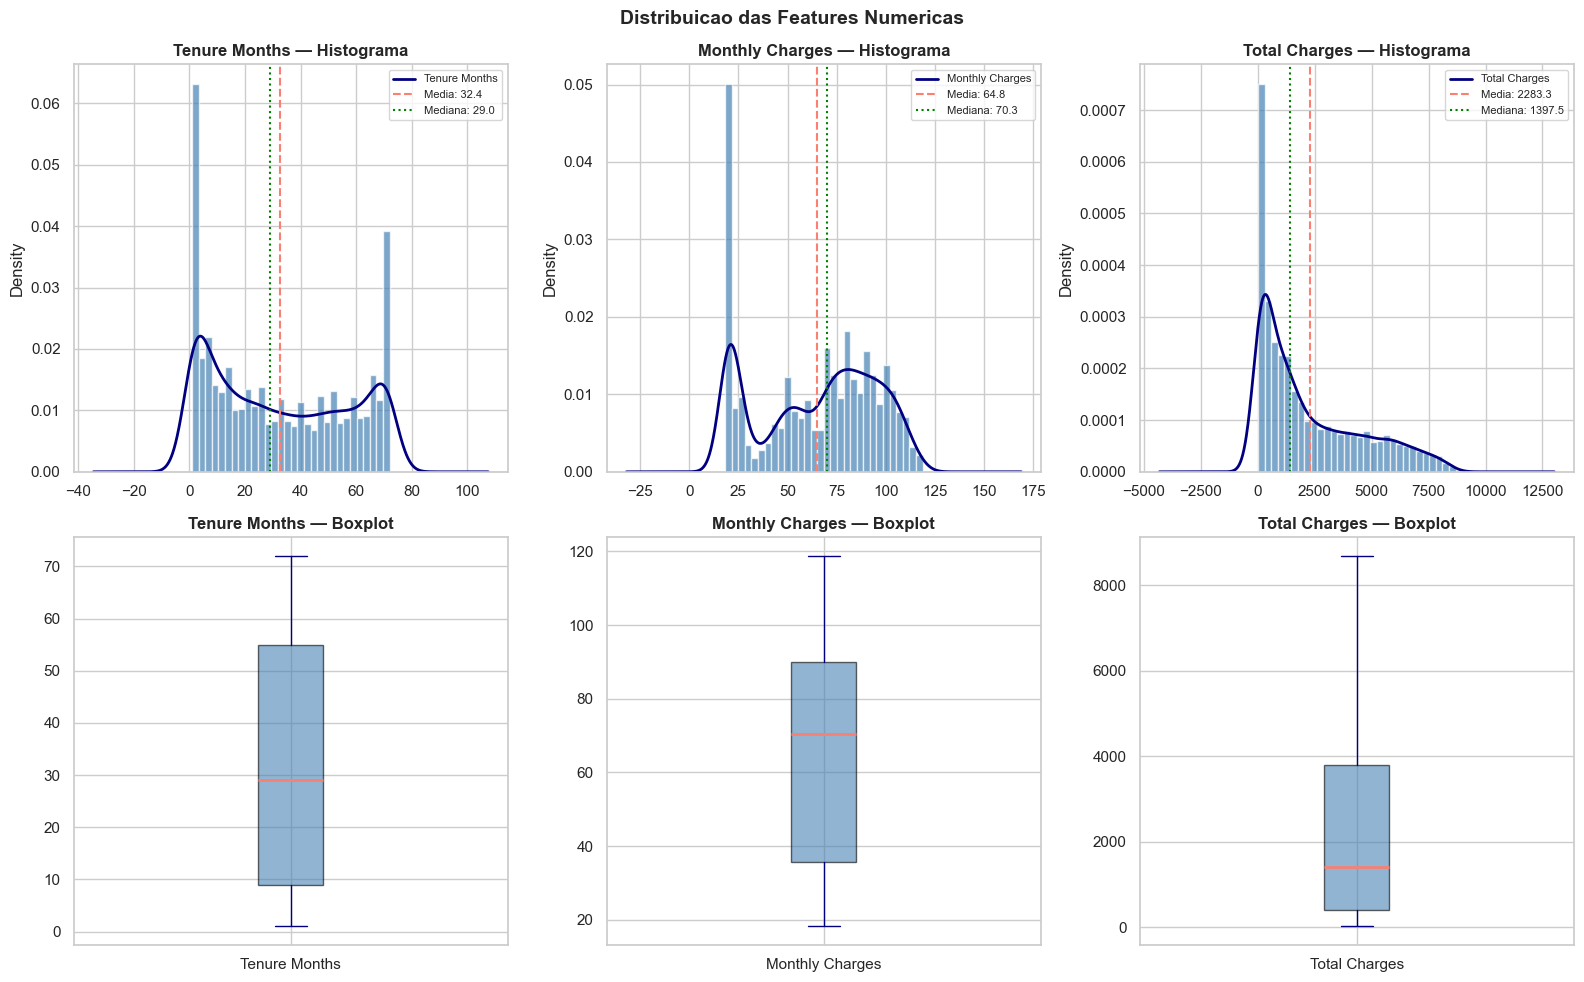

=== ASSIMETRIA E CURTOSE ===



,Media,Mediana,Desvio,Skewness,Kurtosis
Tenure Months,32.42,29.00,24.55,0.238,-1.388
Monthly Charges,64.80,70.35,30.09,-0.222,-1.256
Total Charges,2283.30,1397.48,2266.77,0.962,-0.232


In [9]:
numeric_features = ["Tenure Months", "Monthly Charges", "Total Charges"]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for i, col in enumerate(numeric_features):
    data = df[col]

    # --- Linha 1: Histograma com KDE ---
    ax_hist = axes[0, i]
    ax_hist.hist(data, bins=30, color="steelblue", edgecolor="white", density=True, alpha=0.7)
    data.plot.kde(ax=ax_hist, color="navy", linewidth=2)
    ax_hist.axvline(data.mean(),   color="salmon", linestyle="--", linewidth=1.5, label=f"Media: {data.mean():.1f}")
    ax_hist.axvline(data.median(), color="green",  linestyle=":",  linewidth=1.5, label=f"Mediana: {data.median():.1f}")
    ax_hist.set_title(f"{col} — Histograma", fontweight="bold")
    ax_hist.set_xlabel("")
    ax_hist.legend(fontsize=8)

    # --- Linha 2: Boxplot ---
    ax_box = axes[1, i]
    ax_box.boxplot(
        data, vert=True, patch_artist=True,
        boxprops=dict(facecolor="steelblue", alpha=0.6),
        medianprops=dict(color="salmon", linewidth=2),
        whiskerprops=dict(color="navy"),
        capprops=dict(color="navy"),
        flierprops=dict(marker="o", color="salmon", alpha=0.4, markersize=4),
    )
    ax_box.set_title(f"{col} — Boxplot", fontweight="bold")
    ax_box.set_xticklabels([col])

plt.suptitle("Distribuicao das Features Numericas", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# --- Tabela de estatisticas descritivas ---
import numpy as np

print("=== ASSIMETRIA E CURTOSE ===\n")
stats_df = pd.DataFrame({
    "Media":    df[numeric_features].mean().round(2),
    "Mediana":  df[numeric_features].median().round(2),
    "Desvio":   df[numeric_features].std().round(2),
    "Skewness": df[numeric_features].skew().round(3),
    "Kurtosis": df[numeric_features].kurt().round(3),
})
display(stats_df)

💡 **Observação:**

| Feature | Formato | Interpretação |
|---------|---------|---------------|
| `Tenure Months` | Bimodal (concentrado em 0-5 e 60-72) | Clientes novos e veteranos dominam — poucos no meio-termo |
| `Monthly Charges` | Próxima de uniforme | Planos bem distribuídos por faixa de preço |
| `Total Charges` | Assimetria positiva (cauda direita) | Maioria com baixo total acumulado — reflexo do alto volume de clientes novos |

`Total Charges` com alta assimetria pode se beneficiar de log-transform antes de um modelo linear. Para o MLP com `BatchNorm`, o impacto é menor pois a normalização é aplicada internamente em cada camada.

## 5.2 Distribuição por Classe de Churn — KDE Plots

KDE plots sobrepostos revelam diferenças na forma da distribuição entre clientes com e sem churn, complementando os histogramas anteriores.

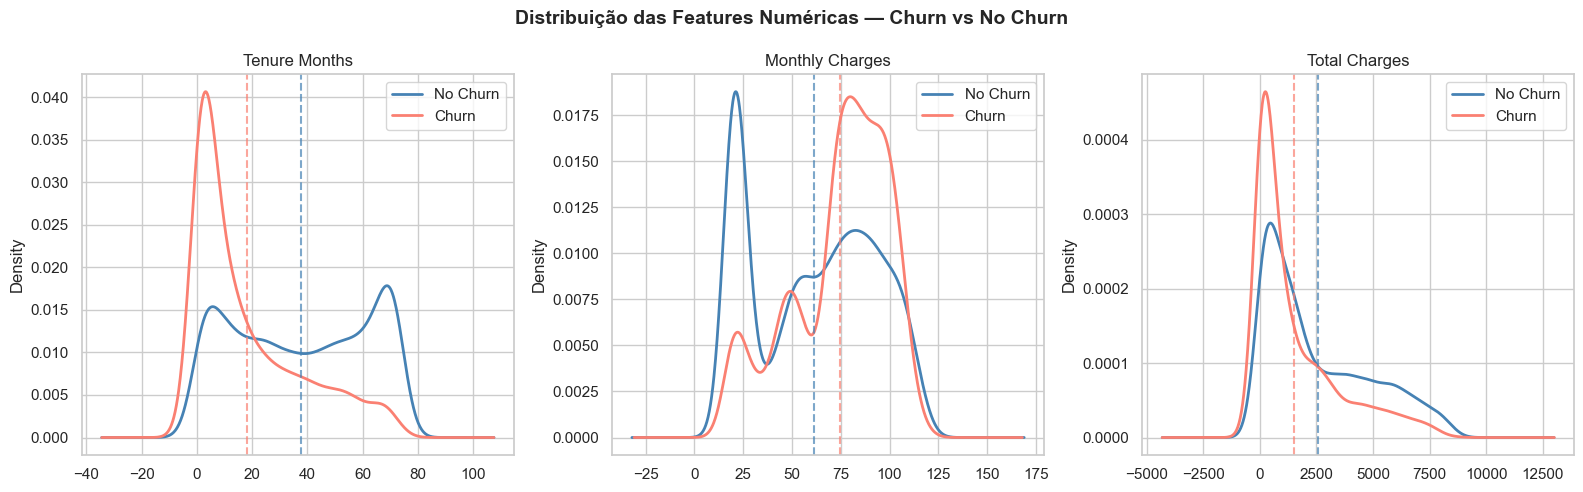

Médias por grupo:


,Tenure Months,Monthly Charges,Total Charges
Churn Value,,,
0,37.65,61.31,2555.34
1,17.98,74.44,1531.80


In [10]:
numeric_features = ["Tenure Months", "Monthly Charges", "Total Charges"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, numeric_features):
    # Separando os grupos para plotar com cores distintas
    churn_yes = df[df["Churn Value"] == 1][col]
    churn_no  = df[df["Churn Value"] == 0][col]

    # KDE (Kernel Density Estimate) suaviza o histograma para facilitar comparação
    churn_no.plot.kde(ax=ax, label="No Churn", color="steelblue", linewidth=2)
    churn_yes.plot.kde(ax=ax, label="Churn", color="salmon", linewidth=2)

    # Linhas verticais nas médias de cada grupo
    ax.axvline(churn_no.mean(), color="steelblue", linestyle="--", alpha=0.7)
    ax.axvline(churn_yes.mean(), color="salmon", linestyle="--", alpha=0.7)

    ax.set_title(col)
    ax.set_xlabel("")
    ax.legend()

plt.suptitle("Distribuição das Features Numéricas — Churn vs No Churn", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Médias por grupo para referência numérica
print("Médias por grupo:")
display(df.groupby("Churn Value")[numeric_features].mean().round(2))


## 5.3 Distribuição por Classe de Churn — Boxplots

Boxplots estratificados por classe de churn são superiores aos KDE plots para identificar **outliers** e comparar medianas e quartis entre grupos. As duas visualizações são complementares: KDE revela a forma da distribuição, boxplot revela a dispersão e os extremos.

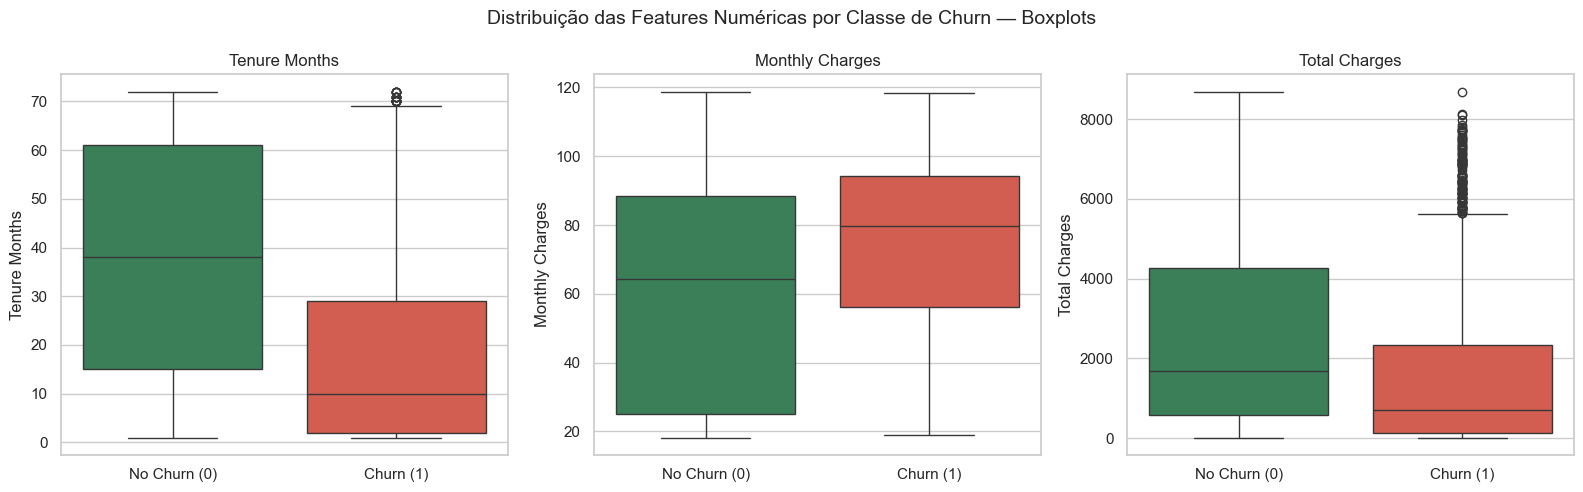

In [11]:
numeric_features = ["Tenure Months", "Monthly Charges", "Total Charges"]
palette = {"0": "#2E8B57", "1": "#E74C3C"}  # chave string: seaborn converte x categorico para str

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Distribuição das Features Numéricas por Classe de Churn — Boxplots", fontsize=14)

for ax, col in zip(axes, numeric_features):
    sns.boxplot(
        data=df.assign(**{"Churn Value": df["Churn Value"].astype(str)}),
        x="Churn Value",
        y=col,
        palette=palette,
        order=["0", "1"],
        ax=ax,
    )
    ax.set_xticklabels(["No Churn (0)", "Churn (1)"])
    ax.set_xlabel("")
    ax.set_title(col)

plt.tight_layout()
plt.show()

💡 **Observação:**

A análise das variáveis numéricas mostra comportamentos distintos entre os clientes que permaneceram e os que cancelaram o serviço:

- **`Tenure Months`**: clientes com churn têm mediana significativamente menor — a maioria cancela nos primeiros meses de contrato. Clientes fiéis (mediana ~38 meses) raramente fazem churn.
- **`Monthly Charges`**: clientes que cancelam pagam mensalidades mais altas. Nota-se também a presença de **outliers** com cobranças elevadas entre os churners — possível insatisfação com o custo-benefício.
- **`Total Charges`**: clientes sem churn acumulam cobranças totais muito maiores, reflexo direto do maior tempo de permanência.

# 🧩 6. Análise das Variáveis Categóricas

Nesta etapa, serão analisadas as variáveis categóricas relevantes para identificar quais categorias estão mais associadas ao churn, utilizando a taxa percentual de cancelamento por grupo.

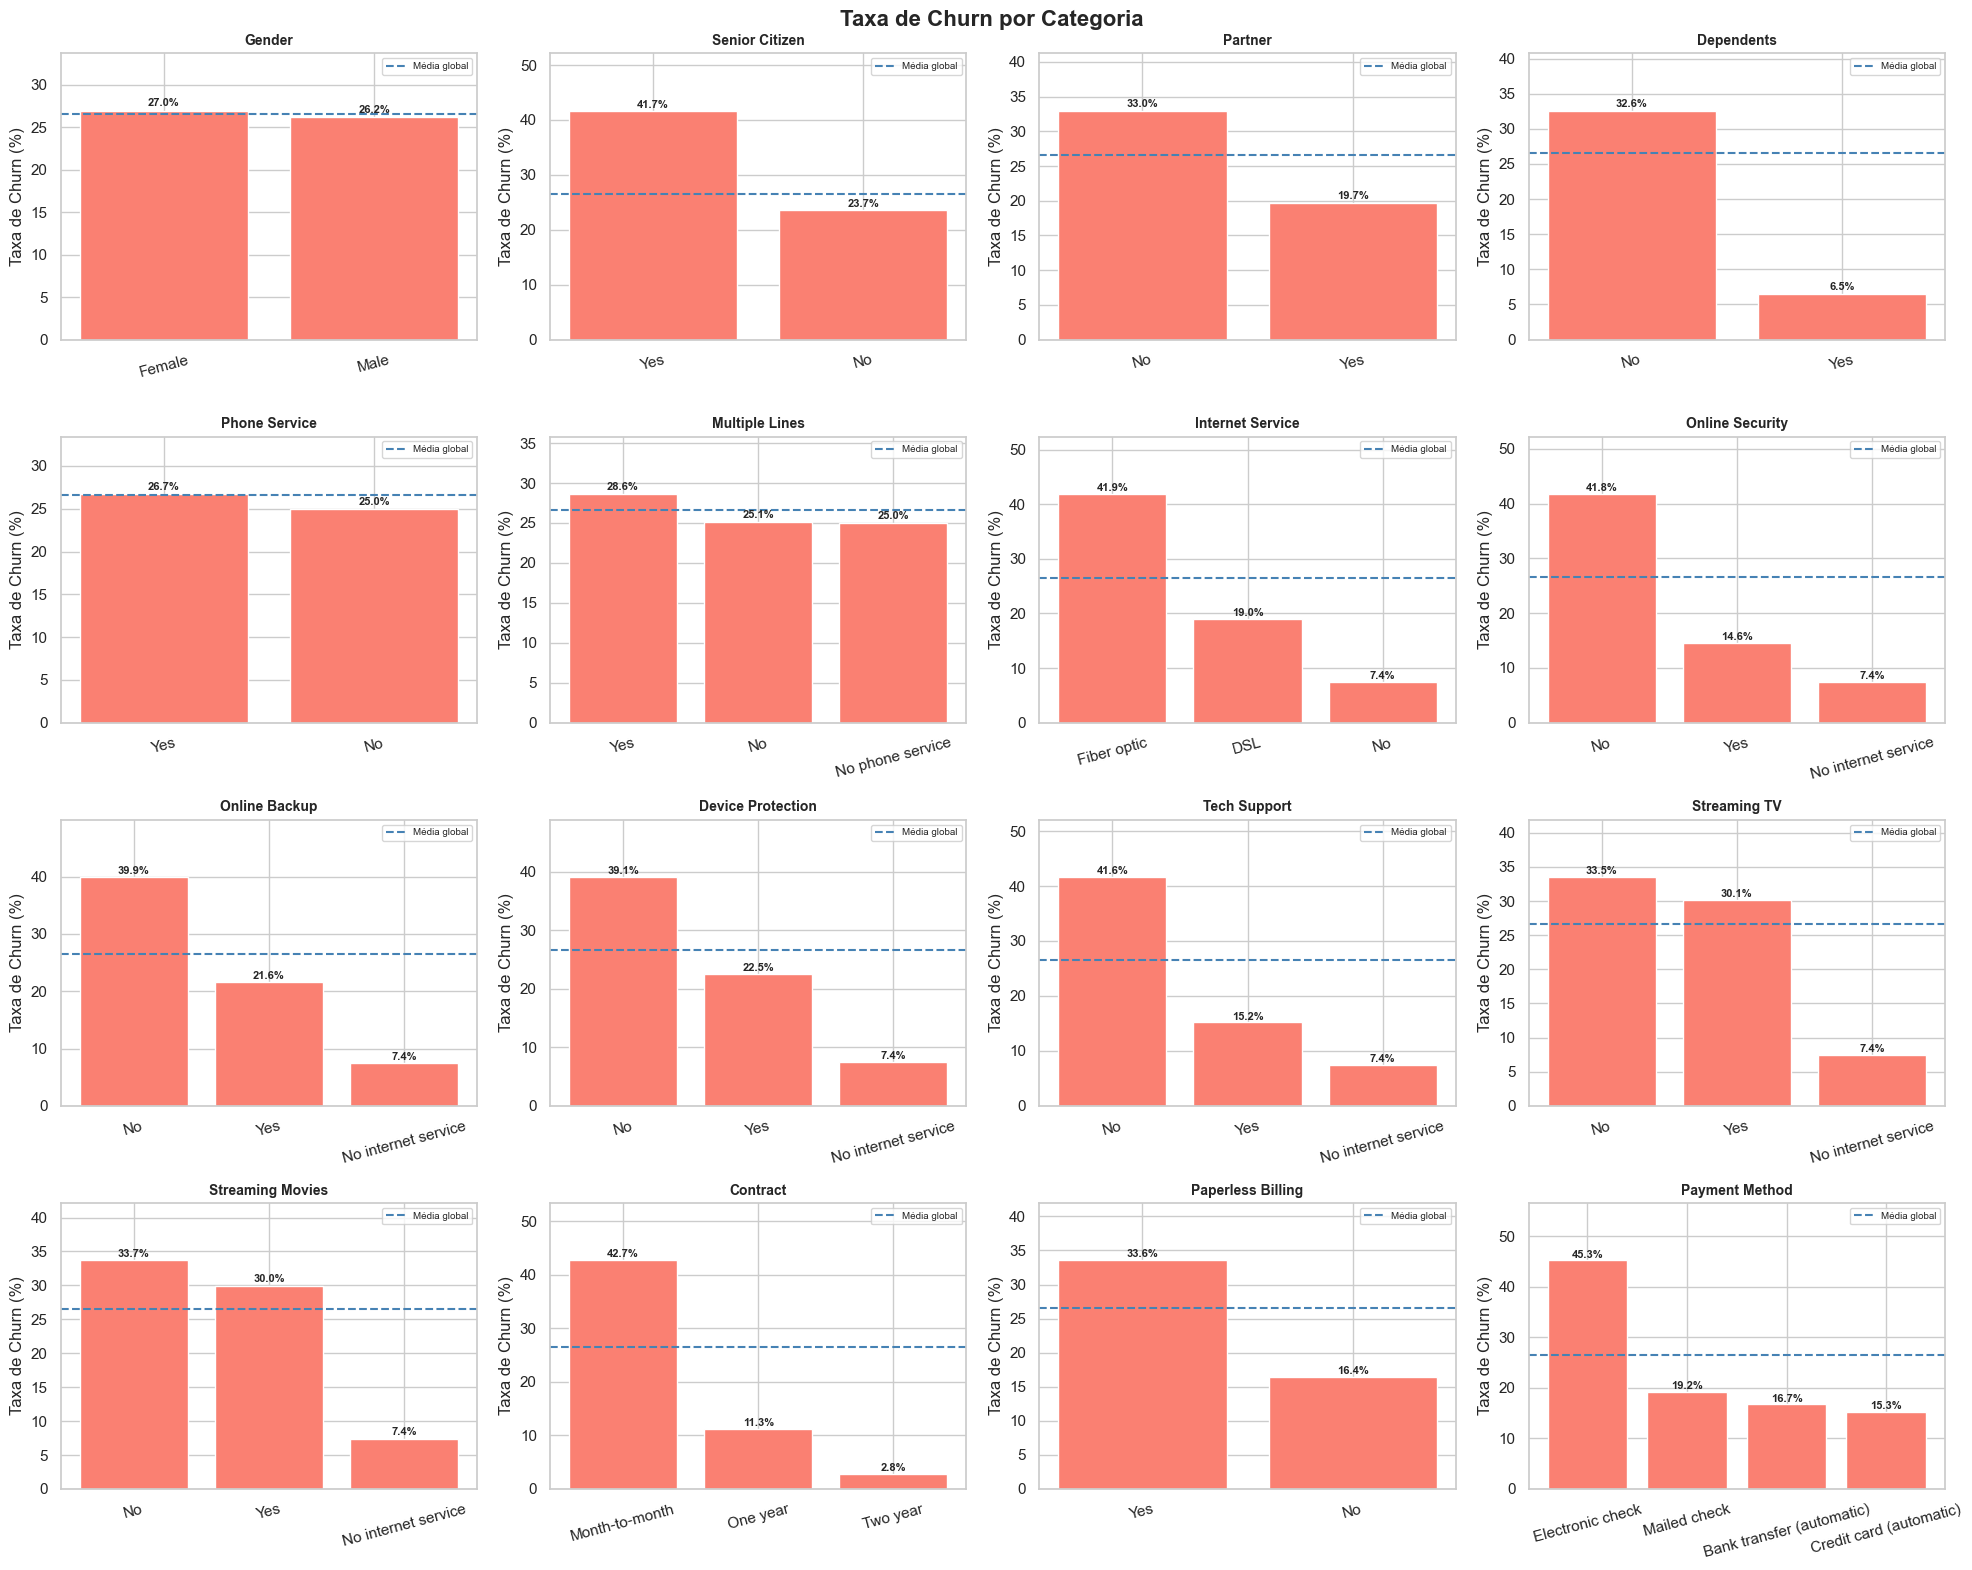

In [12]:
categorical_features = [
    "Gender", "Senior Citizen", "Partner", "Dependents",
    "Phone Service", "Multiple Lines", "Internet Service",
    "Online Security", "Online Backup", "Device Protection",
    "Tech Support", "Streaming TV", "Streaming Movies",
    "Contract", "Paperless Billing", "Payment Method",
]

# 4 colunas por linha para organizar os subplots
n_cols = 4
n_rows = -(-len(categorical_features) // n_cols)  # divisão com teto (ceil)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for ax, col in zip(axes, categorical_features):
    # Taxa de churn (média de Churn Value) por categoria
    churn_rate = (
        df.groupby(col)["Churn Value"]
        .mean()
        .mul(100)
        .sort_values(ascending=False)
    )

    bars = ax.bar(
        churn_rate.index,
        churn_rate.values,
        color="salmon",
        edgecolor="white",
    )

    # Linha de referência: taxa global de churn
    ax.axhline(df["Churn Value"].mean() * 100, color="steelblue",
               linestyle="--", linewidth=1.5, label="Média global")

    # Anotação do percentual em cada barra
    for bar, val in zip(bars, churn_rate.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            val + 0.5,
            f"{val:.1f}%",
            ha="center", fontsize=8, fontweight="bold",
        )

    ax.set_title(col, fontsize=10, fontweight="bold")
    ax.set_ylabel("Taxa de Churn (%)")
    ax.set_ylim(0, churn_rate.max() * 1.25)
    ax.tick_params(axis="x", rotation=15)
    ax.legend(fontsize=7)

# Removendo subplots vazios (se o número de features não preencher a grade)
for ax in axes[len(categorical_features):]:
    ax.set_visible(False)

plt.suptitle("Taxa de Churn por Categoria", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()


💡 **Observação:**

| Feature | Maior risco de churn | Menor risco de churn |
|---------|---------------------|---------------------|
| `Contract` | Month-to-month (~43%) | Two year (~3%) |
| `Internet Service` | Fiber optic (~42%) | No internet (~7%) |
| `Online Security` | No (~42%) | Yes (~15%) |
| `Tech Support` | No (~42%) | Yes (~15%) |
| `Payment Method` | Electronic check (~45%) | Bank transfer (~17%) |
| `Senior Citizen` | Yes (~42%) | No (~24%) |

A análise das variáveis categóricas revelou padrões bastante relevantes. **`Contract`**, **`Internet Service`** e **`Payment Method`** são os maiores discriminadores de churn. Especialmente notável é o caso do **Electronic Check**: clientes que pagam por esse método têm ~45% de churn, contra ~17% dos que usam métodos automáticos (bank transfer, credit card) — sugerindo que a **automação do pagamento está associada a maior retenção**. Esperamos que o modelo atribua alta importância a essas features.

# 🔗 7. Correlação e Relações entre Variáveis

Nesta etapa, serão analisadas as relações entre as variáveis numéricas da base, utilizando matriz de correlação, heatmap e scatterplots bivariados coloridos por classe de churn para identificar padrões de separabilidade entre as classes.

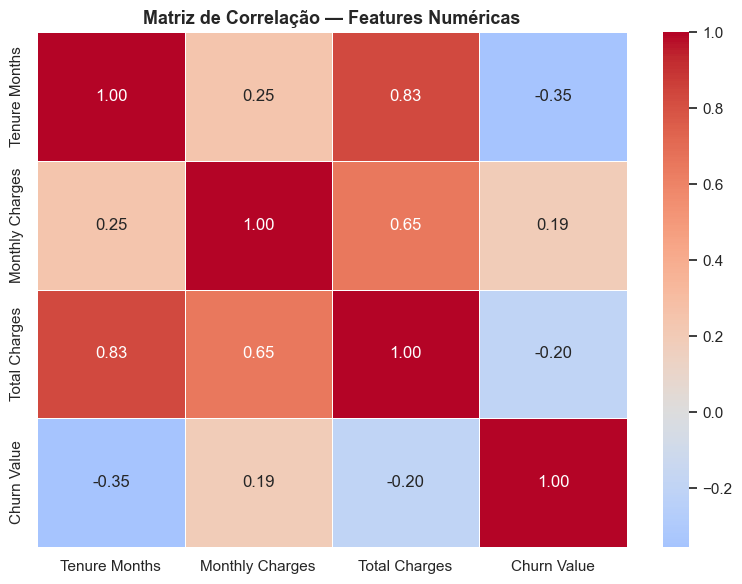

Correlação com Churn Value:


,Churn Value
Tenure Months,-0.354049
Total Charges,-0.199484
Monthly Charges,0.192858


In [13]:
# Selecionando apenas as colunas numéricas para o heatmap
numeric_cols = ["Tenure Months", "Monthly Charges", "Total Charges", "Churn Value"]

corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,          # exibe o valor de correlação em cada célula
    fmt=".2f",
    cmap="coolwarm",     # azul = correlação negativa, vermelho = positiva
    center=0,
    linewidths=0.5,
    ax=ax,
)

ax.set_title("Matriz de Correlação — Features Numéricas", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Correlação de cada feature com o target, ordenada
print("Correlação com Churn Value:")
display(
    corr_matrix["Churn Value"]
    .drop("Churn Value")
    .sort_values(key=abs, ascending=False)
    .to_frame()
    .style.background_gradient(cmap="coolwarm", axis=0)
)


## 7.2 Scatterplots Bivariados por Classe de Churn

Scatterplots coloridos por classe revelam **padrões de separabilidade** que o heatmap de correlação não captura. Se as duas classes formam regiões distintas no plano bivariado, as features têm bom potencial preditivo em conjunto.

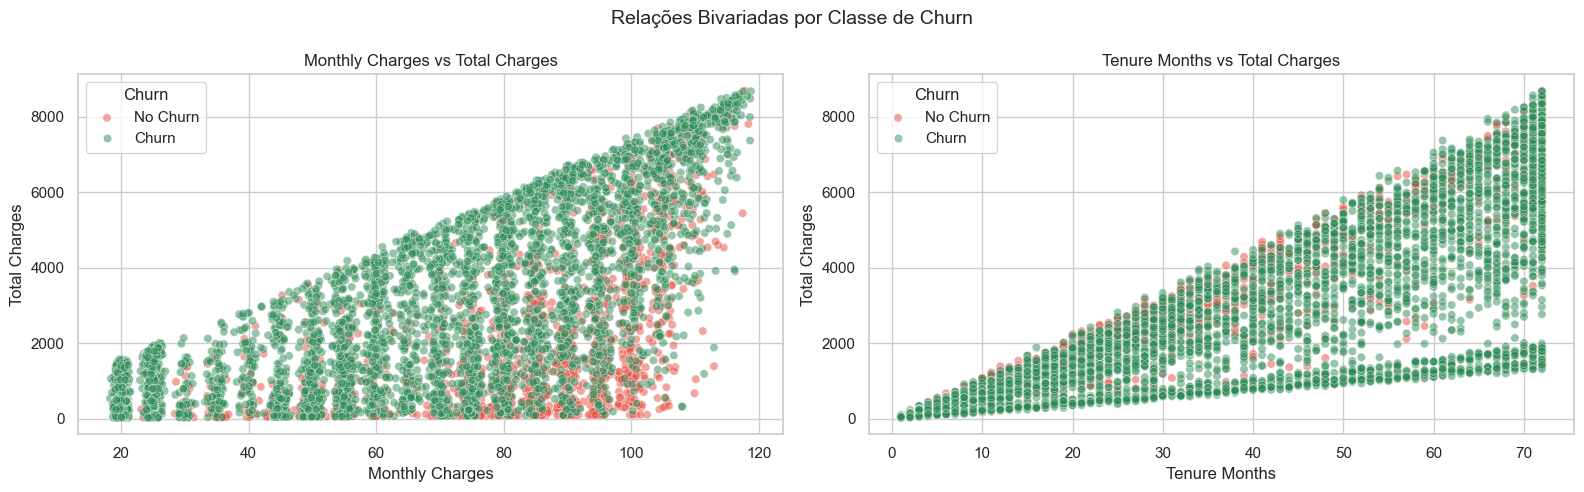

In [14]:
palette_churn = {0: "#2E8B57", 1: "#E74C3C"}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Relações Bivariadas por Classe de Churn", fontsize=14)

# --- Gráfico 1: Monthly Charges vs Total Charges ---
sns.scatterplot(
    data=df,
    x="Monthly Charges",
    y="Total Charges",
    hue="Churn Value",
    palette=palette_churn,
    alpha=0.5,
    ax=axes[0],
)
axes[0].set_title("Monthly Charges vs Total Charges")
axes[0].legend(title="Churn", labels=["No Churn", "Churn"])

# --- Gráfico 2: Tenure Months vs Total Charges ---
sns.scatterplot(
    data=df,
    x="Tenure Months",
    y="Total Charges",
    hue="Churn Value",
    palette=palette_churn,
    alpha=0.5,
    ax=axes[1],
)
axes[1].set_title("Tenure Months vs Total Charges")
axes[1].legend(title="Churn", labels=["No Churn", "Churn"])

plt.tight_layout()
plt.show()

💡 **Observação:**

| Par | Correlação | Interpretação |
|-----|-----------|---------------|
| `Total Charges` × `Tenure Months` | ~0.83 | **Alta multicolinearidade** — `Total Charges` é praticamente uma função linear de `Tenure × Monthly Charges` |
| `Total Charges` × `Monthly Charges` | ~0.65 | Correlação moderada-alta |
| `Tenure Months` × `Churn Value` | ~-0.35 | Quanto mais tempo de contrato, menor o churn |
| `Monthly Charges` × `Churn Value` | ~+0.19 | Mensalidade mais alta associada a maior churn |

Os scatterplots revelam que clientes com churn (vermelho) tendem a se concentrar na **faixa de alta mensalidade e baixo tempo de permanência** — especialmente visível no gráfico `Tenure Months vs Total Charges`, onde os churners ficam no canto inferior esquerdo. Isso confirma que `Tenure Months` e `Monthly Charges` têm bom poder discriminativo conjunto. A **alta multicolinearidade** entre `Total Charges` e `Tenure Months` (0.83) sugere considerar remover `Total Charges` no pipeline — para Regressão Logística, a regularização L2 já mitiga; para o MLP, redes neurais são mais robustas a multicolinearidade.